In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
import seaborn as sns
import bayesflow as bf

import sys
sys.path.append("../")

from src.generative_models import *
from src.priors import pt_prior, mvl_prior

np.set_printoptions(suppress=True)

/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
NUM_SIM = 200
NUM_SAMPLES = 1000

AGENT_LABELS = [
    "Loss averse", "Var averse", "Both aversions", "No aversions",
]
DATA_TYPE = ["New Lotteries", "Old Lotteries"]

FONTSIZE_1 = 20
FONTSIZE_2 = 16
FONTSIZE_3 = 14

In [3]:
import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

## Context

In [4]:
gamble_new = pd.read_csv('../data/lotteries_gain_new.csv')
# gamble_new = gamble_new.loc[gamble_new.ev_diff == 0]
gamble_old = pd.read_csv('../data/lotteries_gain_old.csv')
# gamble_old = gamble_old.loc[gamble_old.ev_diff == 0]

context_new = gamble_new[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

context_old = gamble_old[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

## Agents

In [5]:
pt_tau = 2
mvl_tau = 1.5
b_weights = 0.5
alpha = 0.6
lamda = 2.5

theta_pt_la = np.array([lamda, 1, pt_tau])
theta_pt_var = np.array([1, alpha, pt_tau])
theta_pt_both = np.array([lamda, alpha, pt_tau])
theta_pt_no = np.array([1, 1, pt_tau])

theta_pt = np.array([theta_pt_la, theta_pt_var, theta_pt_both, theta_pt_no])

theta_mvl_la = np.array([0, b_weights, mvl_tau])
theta_mvl_var = np.array([b_weights, 0, mvl_tau])
theta_mvl_both = np.array([b_weights, 0.3, mvl_tau])
theta_mvl_no = np.array([0, 0, mvl_tau])

theta_mvl = np.array([theta_mvl_la, theta_mvl_var, theta_mvl_both, theta_mvl_no])

## Data Simulation

In [6]:
pt_agent_data = np.zeros((2, 4, NUM_SIM, context_new.shape[0], 7))
mvl_agent_data = np.zeros((2, 4, NUM_SIM, context_new.shape[0], 7))

In [7]:
trans_context_new = context_new / 50
trans_context_old = context_old / 50
for i in range(NUM_SIM):
    for j in range(4):
        pt_agent_data[0, j, i, :, 0] = sample_pt_model(theta_pt[j], context_new)
        pt_agent_data[0, j, i, :, 1:] = trans_context_new
        pt_agent_data[1, j, i, :, 0] = sample_pt_model(theta_pt[j], context_old)
        pt_agent_data[1, j, i, :, 1:] = trans_context_old
        mvl_agent_data[0, j, i, :, 0] = sample_mvl_model(theta_mvl[j], context_new)
        mvl_agent_data[0, j, i, :, 1:] = trans_context_new
        mvl_agent_data[1, j, i, :, 0] = sample_mvl_model(theta_mvl[j], context_old)
        mvl_agent_data[1, j, i, :, 1:] = trans_context_old

In [8]:
pt_agent_data_means = pt_agent_data[:, :, :, :, 0].mean(axis=3).mean(axis=2)
mvl_agent_data_means = mvl_agent_data[:, :, :, :, 0].mean(axis=3).mean(axis=2)
pt_agent_data_stds = pt_agent_data[:, :, :, :, 0].mean(axis=3).std(axis=2)
mvl_agent_data_stds = mvl_agent_data[:, :, :, :, 0].mean(axis=3).std(axis=2)

means = [pt_agent_data_means, mvl_agent_data_means]
stds = [pt_agent_data_stds, mvl_agent_data_stds]

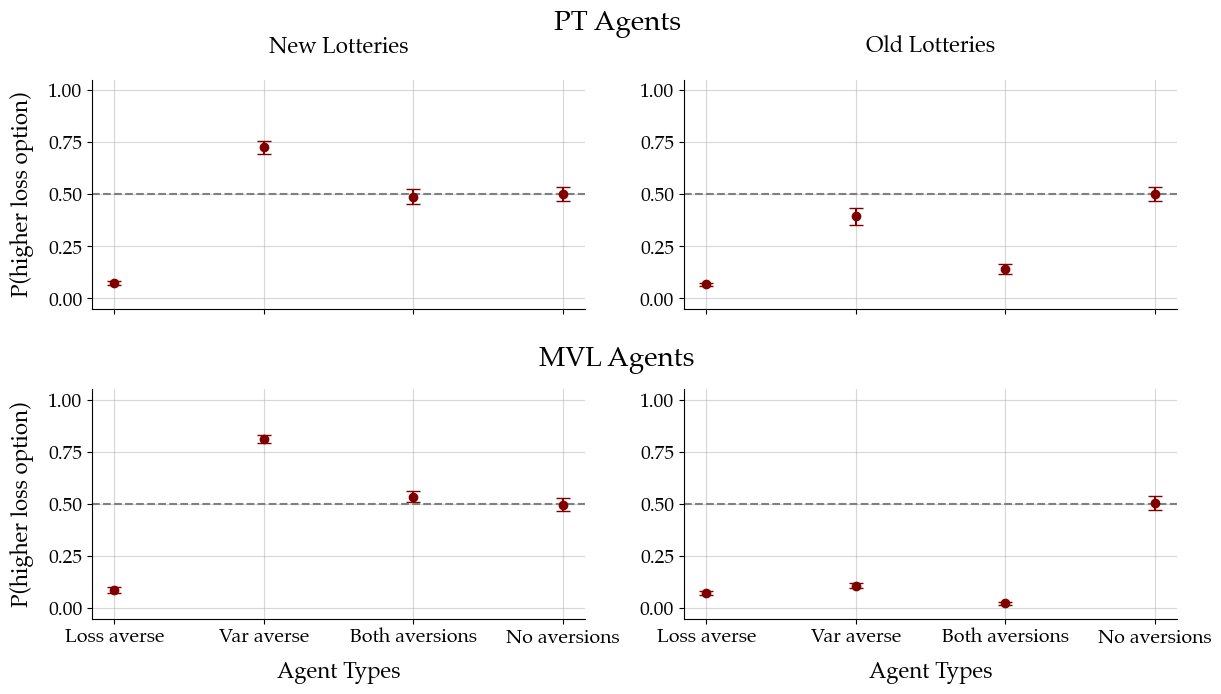

In [9]:
fig, axrr = plt.subplots(2, 2, figsize=(14, 7))
fig.text(0.5, 0.96, 'PT Agents', ha='center', va='center', fontsize=FONTSIZE_1)
fig.text(0.5, 0.48, 'MVL Agents', ha='center', va='center', fontsize=FONTSIZE_1)

for i, ax in enumerate(axrr.flat):
    if i < 2:
        for j in range(4):
            ax.errorbar(
                AGENT_LABELS[j], 1 - means[0][i, j],
                yerr=stds[0][i, j], fmt='o', capsize=5,
                color='maroon', ecolor='maroon'
            )
        ax.set_xticklabels([])
        ax.set_title(DATA_TYPE[i], fontsize=FONTSIZE_2, pad=20)
    if i >= 2:
        for j in range(4):
            ax.errorbar(
                AGENT_LABELS[j], 1 - means[1][i - 2, j],
                yerr=stds[1][i - 2, j], fmt='o', capsize=5,
                color='maroon', ecolor='maroon'
            )
        ax.set_xlabel("Agent Types", fontsize=FONTSIZE_2, labelpad=10)
    if i == 0 or i == 2:
        ax.set_ylabel("P(higher loss option)", fontsize=FONTSIZE_2, labelpad=10)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=0.5, linestyle='--', color='gray', linewidth=1.5)
    ax.grid(alpha=0.5)

sns.despine()
plt.subplots_adjust(hspace=0.35)
plt.savefig("../plots/agent_simulation_summary.pdf", dpi=300, bbox_inches="tight")

## Data Fitting

In [10]:
pt_post_z = np.zeros((2, 4, NUM_SIM, NUM_SAMPLES, 3))
mvl_post_z = np.zeros((2, 4, NUM_SIM, NUM_SAMPLES, 3))

In [11]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(pt_prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [12]:
pt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

pt_trainer = bf.trainers.Trainer(
    generative_model=pt_model, 
    amortizer=pt_amortizer, 
    configurator=pt_configurator, 
    checkpoint_path=f"../checkpoints/pt_model",
    max_to_keep=1
)



INFO:root:Loaded loss history from ../checkpoints/pt_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/pt_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [13]:
for idx in np.ndindex(pt_post_z.shape[:2]):
    i, j = idx
    pt_post_z[i, j] = pt_amortizer.sample(
        {"summary_conditions": pt_agent_data[i, j].astype(np.float32)},
        NUM_SAMPLES
    )

In [14]:
mvl_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

mvl_trainer = bf.trainers.Trainer(
    generative_model=mvl_model, 
    amortizer=mvl_amortizer, 
    configurator=mvl_configurator, 
    checkpoint_path=f"../checkpoints/mvl_model",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/mvl_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/mvl_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [15]:
for idx in np.ndindex(pt_post_z.shape[:2]):
    i, j = idx
    mvl_post_z[i, j] = mvl_amortizer.sample(
        {"summary_conditions": mvl_agent_data[i, j].astype(np.float32)},
        NUM_SAMPLES
    )

In [16]:
pt_post = pt_post_z * PT_PRIOR_STD + PT_PRIOR_MEAN
mvl_post = mvl_post_z * MVL_PRIOR_STD + MVL_PRIOR_MEAN

In [17]:
pt_post_median = np.mean(pt_post, axis=3)
mvl_post_median = np.mean(mvl_post, axis=3)

In [18]:
# loc_scale = np.array([0.07, 0.07, 0.4])
# scale = np.array([0.07, 0.07, 0.4])
# pt_post_median = np.zeros((2, 4, 10, 3))
# for i in range(4):
#     locations_1 = np.random.normal(theta_pt[i], loc_scale)
#     locations_2 = np.random.normal(theta_pt[i], loc_scale)
#     pt_post_median[0, i] = np.random.normal(locations_1, scale, size=(10, 3))
#     pt_post_median[1, i] = np.random.normal(locations_2, scale, size=(10, 3))

In [21]:
shape = mvl_post_median.shape
indices = []
for idx in list(np.ndindex(shape[0], shape[1], shape[3])):
    i, j, k = idx
    indices.append(idx)   
indices = np.array(indices)

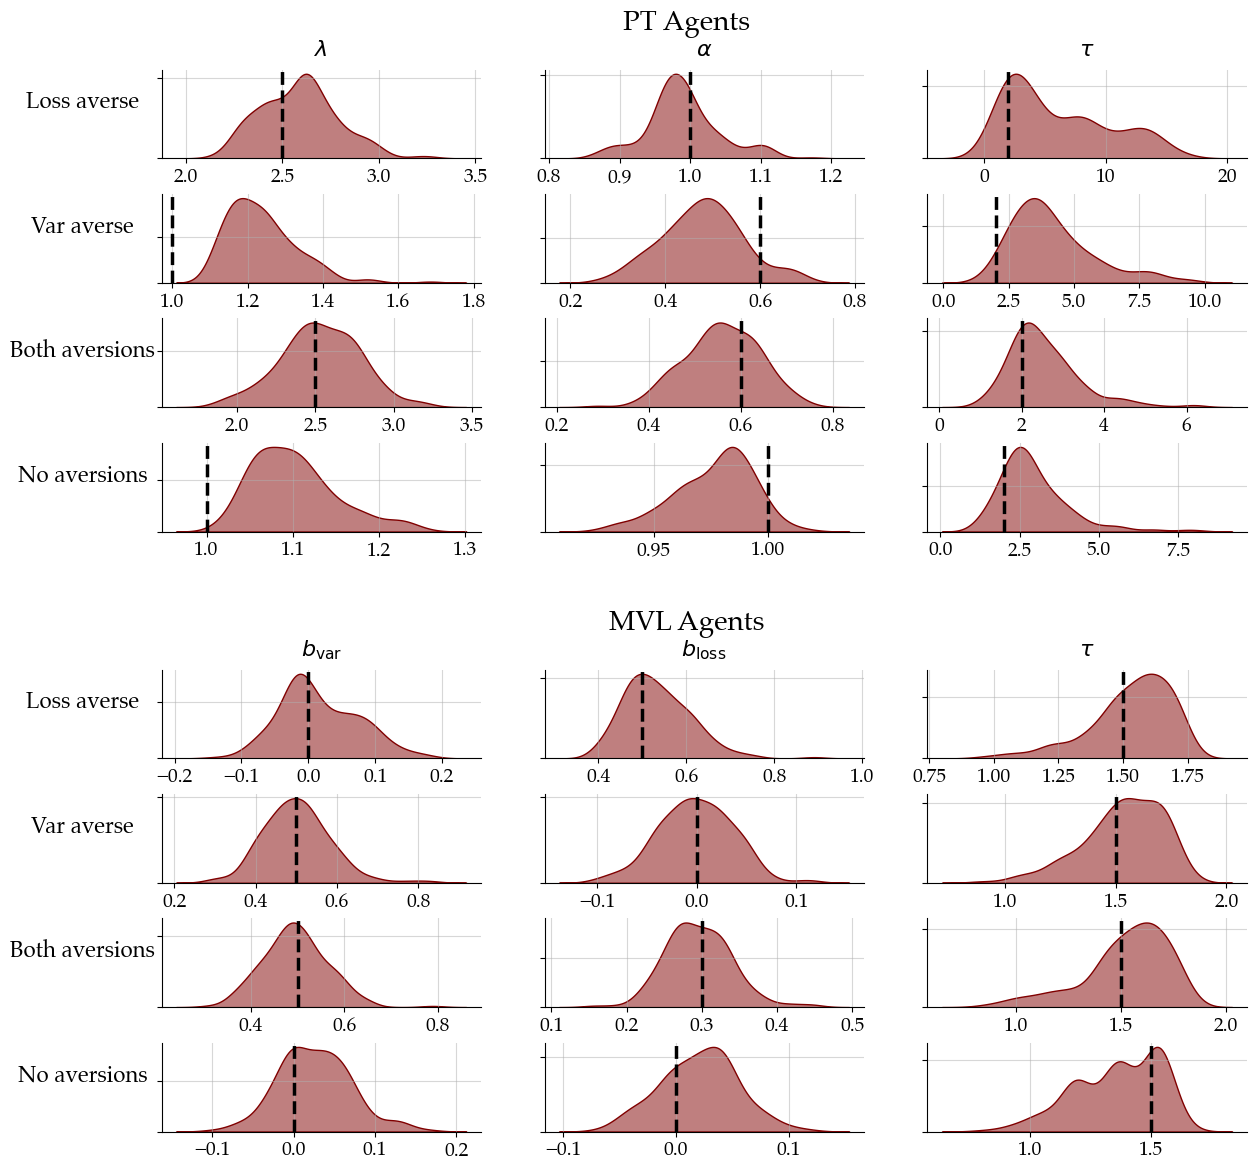

In [22]:
# Create the main figure
fig = plt.figure(figsize=(14, 12))

# Create subfigures
subfigs = fig.subfigures(2, 1, height_ratios=[1, 1])

# Add titles to subfigures
subfigs[0].suptitle('PT Agents', fontsize=FONTSIZE_1)
subfigs[1].suptitle('MVL Agents', fontsize=FONTSIZE_1)

# Create subplots for PT Agents
axrr_pt = subfigs[0].subplots(4, 3)
for i, ax in enumerate(axrr_pt.flat):
    j, g, k = indices[i]
    j = 0
    sns.kdeplot(pt_post_median[j, g, :, k], ax=ax, color='maroon', fill=True, alpha=0.5)
    ax.axvline(x=theta_pt[g][k], linestyle='--', color='black', linewidth=2.5)
    if i % 3 == 0:
        ax.set_ylabel(AGENT_LABELS[g], fontsize=FONTSIZE_2, labelpad=50, rotation=0)
    else:
        ax.set_ylabel("")
    if i < 3:
        ax.set_title(pt_prior.param_names[k], fontsize=FONTSIZE_2, pad=10)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    ax.set_yticklabels([])
    ax.grid(alpha=0.5)

# Create subplots for MVL Agents
axrr_mvl = subfigs[1].subplots(4, 3)
for i, ax in enumerate(axrr_mvl.flat):
    j, g, k = indices[i]
    sns.kdeplot(mvl_post_median[j, g, :, k], ax=ax, color='maroon', fill=True, alpha=0.5)
    ax.axvline(x=theta_mvl[g][k], linestyle='--', color='black', linewidth=2.5)
    if i % 3 == 0:
        ax.set_ylabel(AGENT_LABELS[g], fontsize=FONTSIZE_2, labelpad=50, rotation=0)
    else:
        ax.set_ylabel("")
    if i < 3:
        ax.set_title(mvl_prior.param_names[k], fontsize=FONTSIZE_2, pad=10)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    ax.set_yticklabels([])
    ax.grid(alpha=0.5)

sns.despine()
fig.subplots_adjust(hspace=0.1)  # Adjust overall vertical spacing between subfigures
subfigs[0].subplots_adjust(hspace=0.4)  # Adjust vertical spacing within the first subfigure
subfigs[1].subplots_adjust(hspace=0.4)  # Adjust vertical spacing within the second subfigure
plt.savefig("../plots/agent_simulation_new_recovery.pdf", dpi=300, bbox_inches="tight")

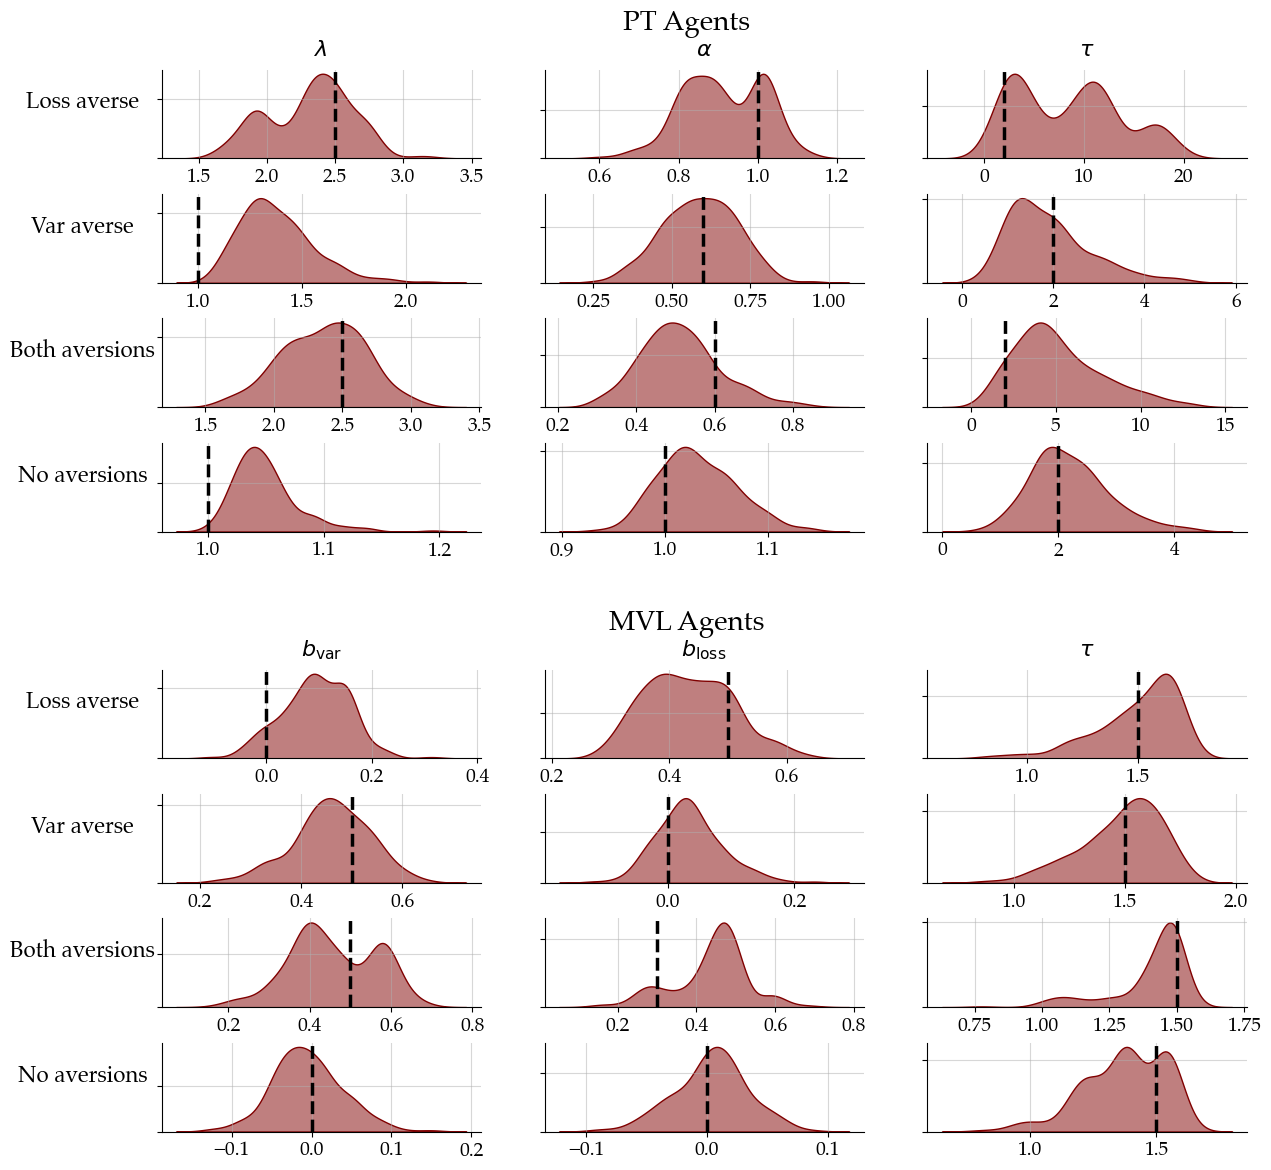

In [ ]:
# Create the main figure
fig = plt.figure(figsize=(14, 12))

# Create subfigures
subfigs = fig.subfigures(2, 1, height_ratios=[1, 1])

# Add titles to subfigures
subfigs[0].suptitle('PT Agents', fontsize=FONTSIZE_1)
subfigs[1].suptitle('MVL Agents', fontsize=FONTSIZE_1)

# Create subplots for PT Agents
axrr_pt = subfigs[0].subplots(4, 3)
for i, ax in enumerate(axrr_pt.flat):
    j, g, k = indices[i]
    j = 1
    sns.kdeplot(pt_post_median[j, g, :, k], ax=ax, color='maroon', fill=True, alpha=0.5)
    ax.axvline(x=theta_pt[g][k], linestyle='--', color='black', linewidth=2.5)
    if i % 3 == 0:
        ax.set_ylabel(AGENT_LABELS[g], fontsize=FONTSIZE_2, labelpad=50, rotation=0)
    else:
        ax.set_ylabel("")
    if i < 3:
        ax.set_title(pt_prior.param_names[k], fontsize=FONTSIZE_2, pad=10)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    ax.set_yticklabels([])
    ax.grid(alpha=0.5)

# Create subplots for MVL Agents
axrr_mvl = subfigs[1].subplots(4, 3)
for i, ax in enumerate(axrr_mvl.flat):
    j, g, k = indices[i]
    j = 1
    sns.kdeplot(mvl_post_median[j, g, :, k], ax=ax, color='maroon', fill=True, alpha=0.5)
    ax.axvline(x=theta_mvl[g][k], linestyle='--', color='black', linewidth=2.5)
    if i % 3 == 0:
        ax.set_ylabel(AGENT_LABELS[g], fontsize=FONTSIZE_2, labelpad=50, rotation=0)
    else:
        ax.set_ylabel("")
    if i < 3:
        ax.set_title(mvl_prior.param_names[k], fontsize=FONTSIZE_2, pad=10)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    ax.set_yticklabels([])
    ax.grid(alpha=0.5)

sns.despine()
fig.subplots_adjust(hspace=0.1)  # Adjust overall vertical spacing between subfigures
subfigs[0].subplots_adjust(hspace=0.4)  # Adjust vertical spacing within the first subfigure
subfigs[1].subplots_adjust(hspace=0.4)  # Adjust vertical spacing within the second subfigure
plt.savefig("../plots/agent_simulation_old_recovery.pdf", dpi=300, bbox_inches="tight")
